<a href="https://colab.research.google.com/github/M1kr03x/neuroSystems/blob/main/PR2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практическая работа №2 "Создание конкуртной нейронной сети"

**Цель работы:** изучить топологию и алгоритм функционирования конкурентной нейронной сети.

## Порядок выполнения работы

1. Ознакомиться с теоретической частью по конкурентным нейронным сетям.
2. Реализовать конкурентную нейронную сеть в Python в среде Google Colab.
3. Подготовить набор идеальных образов размером $6 \times 6$ в соответствии с вариантом задания.
4. Преобразовать каждый образ в вектор входных данных.
5. Выполнить нормировку входных векторов.
6. Сформировать матрицу весовых коэффициентов и выполнить её нормировку.
7. Обучить сеть по правилу конкурентного обучения с использованием критерия:
   $KRIT_j = f_j \cdot \|X_j^{norm} - W_j^{norm}\|$
8. Определить нейрон-победитель по минимальному значению критерия:
   $K_{min} = p$, если $KRIT_p < KRIT_j$ для всех $j \ne p$
9. После определения победителя увеличить счётчик его побед:
   $f_{K_{min}} = f_{K_{min}} + 1$
10. Выполнить коррекцию весов нейрона-победителя:
$$
\Delta W^{K_{\min}}_{\text{norm}} = \mu \left( X^{K_{\min}}_{\text{norm}} - W^{K_{\min}}_{\text{norm}} \right)
$$
11. Повторять обучение до устойчивого распределения образов по кластерам.
12. Создать зашумлённые тестовые образы с искажением 10%, 20%, 30% и 40%.
13. Подать тестовые образы на вход сети и определить, к какому кластеру они отнесены.
14. Проверить работу сети при числе выходных нейронов, меньшем числа образов.
15. Провести серию экспериментов при разных значениях числа выходных нейронов: `m = 5`, `m = 4`, `m = 3`.
16. Для каждого значения `m` определить, как распределяются по кластерам идеальные и зашумлённые образы.
17. Исследовать влияние скорости обучения, выполнив эксперименты при `h = 0.01`, `h = 0.05`, `h = 0.1`.
18. Для каждого значения `h` сравнить устойчивость распознавания образов при уровнях шума 10%, 20%, 30% и 40%.
19. Сравнить результаты всех проведённых экспериментов и определить, при каких значениях `h` сеть работает наиболее устойчиво.
20. Сделать выводы о способности конкурентной сети выполнять кластеризацию и распознавание зашумлённых образов.

### Таблица вариантов заданий

| № варианта | 1-й класс | 2-й класс | 3-й класс | 4-й класс | 5-й класс |
|---|---|---|---|---|---|
| 18 | F | G | H | J | K |

## Ход работы
В работе реализуется конкурентная нейронная сеть для распознавания 5 образов размером $6 \times 6$: *F, G, H, J, K*.

Алгоритм выполнения:
1. Задаются идеальные бинарные образы.
2. Для каждого образа создаются зашумлённые версии с искажением 10%, 20%, 30% и 40%.
3. Все изображения преобразуются в векторы длины 36.
4. Выполняется обучение конкурентной нейронной сети.
5. Для каждого входного образа определяется нейрон-победитель.
6. Результаты представляются в виде матрицы кластеров.

В качестве критерия выбора нейрона-победителя используется выражение:

$KRIT_j = f_j \cdot \|X - W_j\|$

где:
- $X$ — входной вектор,
- $W_j$ — вектор весов $j$-го нейрона,
- $f_j$ — число побед $j$-го нейрона.

Победителем считается нейрон, для которого значение критерия минимально.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import math

np.random.seed(42)

# ============================================
# 1. Исходные образы 6x6
# ============================================

# →
F = np.array([
    [1, 0, 0, 0, 0, 1],
    [0, 1, 1, 1, 1, 0],
    [0, 1, 0, 0, 1, 0],
    [0, 1, 0, 0, 1, 0],
    [0, 1, 1, 1, 0, 1],
    [1, 0, 0, 1, 1, 1]
], dtype=float)

# ↔
G = np.array([
    [1, 1, 0, 0, 1, 1],
    [1, 0, 1, 1, 0, 1],
    [1, 0, 1, 1, 0, 1],
    [1, 0, 1, 1, 0, 1],
    [1, 0, 1, 1, 0, 1],
    [1, 1, 0, 0, 1, 1]
], dtype=float)

# ←
H = np.array([
    [1, 1, 0, 0, 1, 1],
    [1, 0, 1, 1, 0, 1],
    [1, 0, 1, 1, 0, 1],
    [1, 0, 1, 1, 0, 1],
    [1, 0, 1, 1, 0, 1],
    [1, 1, 0, 0, 1, 0]
], dtype=float)

# ↓
J = np.array([
    [1, 1, 0, 0, 1, 1],
    [1, 0, 1, 1, 1, 1],
    [1, 0, 1, 1, 1, 1],
    [1, 0, 1, 1, 1, 1],
    [1, 0, 1, 1, 1, 1],
    [1, 1, 0, 0, 1, 1]
], dtype=float)

# ↲
K = np.array([
    [1, 1, 0, 0, 1, 1],
    [1, 0, 1, 1, 0, 1],
    [1, 0, 1, 0, 0, 1],
    [1, 0, 0, 1, 0, 1],
    [1, 0, 1, 1, 0, 1],
    [1, 1, 0, 0, 1, 1]
], dtype=float)

base_images = {
    "F": F,
    "G": G,
    "H": H,
    "J": J,
    "K": K
}

In [3]:
# ============================================
# 2. Вспомогательные функции
# ============================================

def to_vector(img):
    return img.T.reshape(-1).astype(float)

def normalize_vector(x):
    norm = np.linalg.norm(x)
    return x / norm if norm != 0 else x

def add_noise(img, flips):
    noisy = img.copy().reshape(-1)
    idx = np.random.choice(len(noisy), size=flips, replace=False)
    noisy[idx] = 1 - noisy[idx]
    return noisy.reshape(img.shape)

def show_images(images_dict, title):
    fig, axes = plt.subplots(1, len(images_dict), figsize=(14, 3))
    fig.suptitle(title, fontsize=14)
    for ax, (name, img) in zip(axes, images_dict.items()):
        ax.imshow(img, cmap="gray_r")
        ax.set_title(name)
        ax.axis("off")
    plt.show()

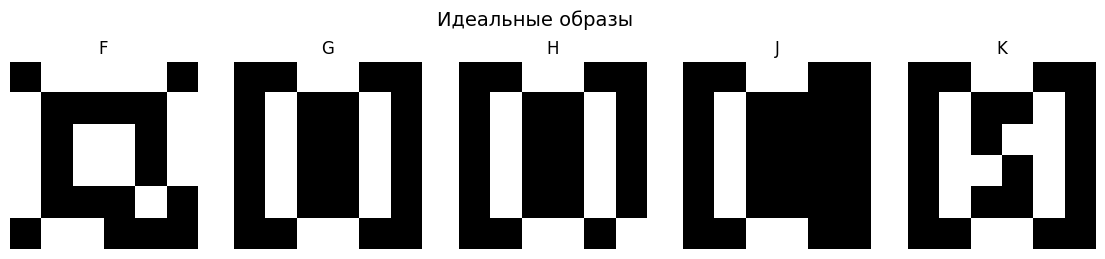

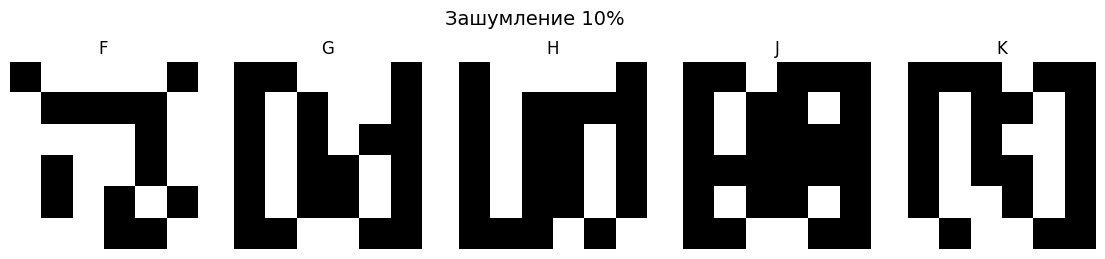

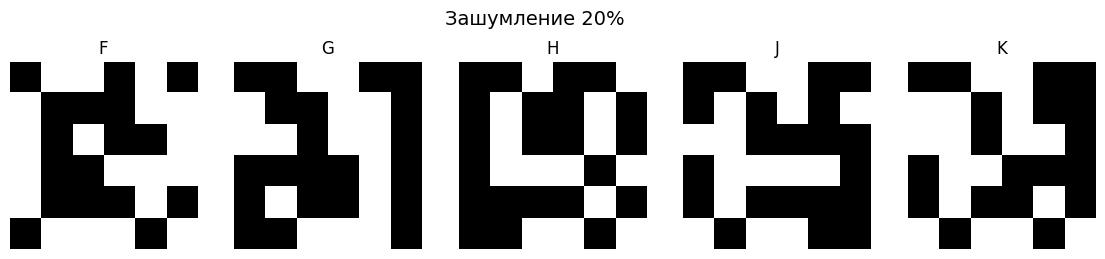

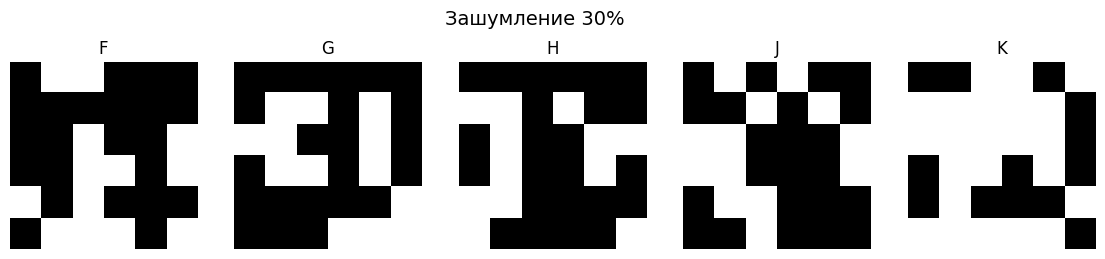

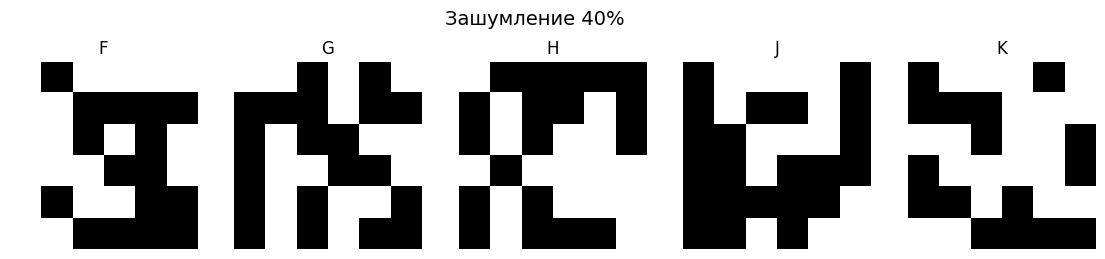

In [4]:
# ============================================
# 3. Создание зашумленных образов
# ============================================

noise_levels = {
    "0%": 0,
    "10%": 4,
    "20%": 7,
    "30%": 11,
    "40%": 14
}

all_images = {}
for noise_name, flips in noise_levels.items():
    all_images[noise_name] = {}
    for label, img in base_images.items():
        if flips == 0:
            all_images[noise_name][label] = img.copy()
        else:
            all_images[noise_name][label] = add_noise(img, flips)

show_images(base_images, "Идеальные образы")
show_images(all_images["10%"], "Зашумление 10%")
show_images(all_images["20%"], "Зашумление 20%")
show_images(all_images["30%"], "Зашумление 30%")
show_images(all_images["40%"], "Зашумление 40%")

In [6]:
# ============================================
# 4. Подготовка обучающей выборки
# ============================================

train_labels = list(base_images.keys())
X_train = np.array([normalize_vector(to_vector(base_images[label])) for label in train_labels])

# ============================================
# 5. Обучение конкурентной сети
# ============================================

def train_competitive_network(X, m=5, h=0.05, epochs=30, seed=42):
    np.random.seed(seed)
    n = X.shape[1]

    W = np.random.rand(n, m) * 2 - 1
    for j in range(m):
        W[:, j] = normalize_vector(W[:, j])

    f = np.ones(m)

    for _ in range(epochs):
        for x in X:
            krit = [0.0 for _ in range(m)]

            # вычисление KRIT_j
            for j in range(m):
                s = 0.0
                for i in range(n):
                    s += (x[i] - W[i][j]) ** 2
                krit[j] = math.sqrt(s) * f[j]

            # поиск нейрона-победителя
            winner = 0
            min_value = krit[0]
            for j in range(1, m):
                if krit[j] < min_value:
                    min_value = krit[j]
                    winner = j

            # увеличение счетчика побед
            f[winner] += 1

            # коррекция весов нейрона-победителя
            for i in range(n):
                W[i][winner] = W[i][winner] + h * (x[i] - W[i][winner])

    return W, f

In [7]:
# ============================================
# 6. Классификация образов
# ============================================

def predict_cluster(x, W, f):
    x = normalize_vector(x)
    krit = np.array([np.linalg.norm(x - W[:, j]) * f[j] for j in range(W.shape[1])])
    return np.argmin(krit) + 1  # нумерация с 1

def evaluate_network(all_images, W, f):
    labels = ["F", "G", "H", "J", "K"]
    levels = ["0%", "10%", "20%", "30%", "40%"]
    result = np.zeros((5, 5), dtype=int)

    for i, label in enumerate(labels):
        for j, level in enumerate(levels):
            x = to_vector(all_images[level][label])
            result[i, j] = predict_cluster(x, W, f)

    return result

In [8]:
# ============================================
# 7. Эксперимент 1: m = 5
# ============================================

W5, f5 = train_competitive_network(X_train, m=5, h=0.05, epochs=30, seed=42)
REZ5 = evaluate_network(all_images, W5, f5)

print("Результат для m = 5")
print("Строки: F, G, H, J, K")
print("Столбцы: 0%, 10%, 20%, 30%, 40%")
print(REZ5)

Результат для m = 5
Строки: F, G, H, J, K
Столбцы: 0%, 10%, 20%, 30%, 40%
[[1 1 4 4 4]
 [5 4 4 4 4]
 [5 4 4 4 4]
 [2 4 4 4 4]
 [3 4 4 4 4]]


In [9]:
# ============================================
# 8. Эксперимент 2: m = 4
# ============================================

W4, f4 = train_competitive_network(X_train, m=4, h=0.05, epochs=30, seed=42)
REZ4 = evaluate_network(all_images, W4, f4)

print("Результат для m = 4")
print("Строки: F, G, H, J, K")
print("Столбцы: 0%, 10%, 20%, 30%, 40%")
print(REZ4)

Результат для m = 4
Строки: F, G, H, J, K
Столбцы: 0%, 10%, 20%, 30%, 40%
[[3 3 3 3 3]
 [2 4 4 4 1]
 [2 4 4 1 4]
 [1 1 1 1 4]
 [4 4 4 4 4]]


In [10]:
# ============================================
# 9. Эксперимент 3: m = 3
# ============================================

W3, f3 = train_competitive_network(X_train, m=3, h=0.05, epochs=30, seed=42)
REZ3 = evaluate_network(all_images, W3, f3)

print("Результат для m = 3")
print("Строки: F, G, H, J, K")
print("Столбцы: 0%, 10%, 20%, 30%, 40%")
print(REZ3)

Результат для m = 3
Строки: F, G, H, J, K
Столбцы: 0%, 10%, 20%, 30%, 40%
[[1 1 1 1 1]
 [3 2 2 2 1]
 [3 2 2 2 1]
 [2 2 2 1 1]
 [2 2 2 2 1]]


In [12]:
# ============================================
# 10. Исследование влияния скорости обучения
# ============================================

for h in [0.01, 0.05, 0.1]:
    W_h, f_h = train_competitive_network(X_train, m=5, h=h, epochs=30, seed=42)
    REZ_h = evaluate_network(all_images, W_h, f_h)
    print(f"\nРезультат для h = {h}, m = 5")
    print("Строки: F, G, H, J, K")
    print("Столбцы: 0%, 10%, 20%, 30%, 40%")
    print(REZ_h)


Результат для h = 0.01, m = 5
Строки: F, G, H, J, K
Столбцы: 0%, 10%, 20%, 30%, 40%
[[4 5 4 3 5]
 [2 5 1 1 3]
 [1 3 3 2 2]
 [5 5 5 1 3]
 [3 3 5 2 4]]

Результат для h = 0.05, m = 5
Строки: F, G, H, J, K
Столбцы: 0%, 10%, 20%, 30%, 40%
[[1 1 4 4 4]
 [5 4 4 4 4]
 [5 4 4 4 4]
 [2 4 4 4 4]
 [3 4 4 4 4]]

Результат для h = 0.1, m = 5
Строки: F, G, H, J, K
Столбцы: 0%, 10%, 20%, 30%, 40%
[[1 4 4 4 4]
 [5 4 4 4 4]
 [5 4 4 4 4]
 [2 4 4 4 4]
 [3 4 4 4 4]]


**Вывод**: Разработанная конкурентная нейронная сеть успешно справляется с кластеризацией идеальных образов размером 6x6, эффективно распределяя их по категориям благодаря правильной нормировке входных данных и весов. При этом точность работы сети критически зависит от начальной инициализации весовых коэффициентов и использования счетчика побед, который предотвращает доминирование одного нейрона и обеспечивает равномерное обучение всех элементов сети.

## Контрольные вопросы

1. В чём заключается смысл самообучения нейронной сети?

Смысл в том, что сеть сама находит закономерности в данных без учителя, ей не нужно заранее говорить, к какому классу относится каждый образ. Она сама группирует похожие входные данные в кластеры, подстраивая свои веса в процессе обучения.

2. Как выполняется обучение конкурентной нейронной сети?

На вход подаётся образ, для каждого нейрона вычисляется расстояние между входным вектором и его весами. Нейрон с наименьшим расстоянием побеждает, и его веса корректируются, сдвигаются ближе к входному вектору. Это повторяется много раз (эпох), пока распределение по кластерам не станет устойчивым.

3. Каким образом определяется нейрон-победитель в конкурентной нейронной сети?

В качестве критерия выбора нейрона-победителя используется выражение:
$KRIT_j = f_j \cdot \|X - W_j\|$, где: $X$ — входной вектор, $W_j$ — вектор весов $j$-го нейрона, $f_j$ — число побед $j$-го нейрона. Победителем считается нейрон, для которого значение критерия минимально. Множитель f нужен, чтобы один нейрон не побеждал постоянно.

4. Где используются самоорганизующиеся нейронные сети?

Используются для кластеризации данных, сжатия информации, распознавания образов, анализа текстов, сегментации изображений.

5. Каковы основные достоинства и недостатки конкурентной нейронной сети?

Достоинства: не нужен учитель, сеть сама находит структуру в данных, простая реализация, может работать с неизвестными заранее классами.

Недостатки: результат зависит от начальных весов и параметров (скорость обучения, число нейронов), плохо работает при сильном шуме, нет гарантии оптимального разбиения на кластеры.